# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO
print("Số dòng:", df.shape[0], "Số cột:", df.shape[1])
df.info()

Số dòng: 891 Số cột: 15
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [15]:
# TODO
missing = df.isnull().sum()
print("Số cột thiếu dữ liệu:")
# A if dk else B
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu" )
print("Số lượng dữ liệu trùng:", df.duplicated().sum())

Số cột thiếu dữ liệu:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
Số lượng dữ liệu trùng: 107


## A.3. Invalid values

In [35]:
# TODO
print("Số tuổi <=0:", (df['age']<=0).sum())
print(df['alive'].value_counts(), df['survived'].value_counts())
print("pclass:", (df['pclass'].value_counts()), "class:", (df['class'].value_counts()))
df

Số tuổi <=0: 0
alive
no     549
yes    342
Name: count, dtype: int64 survived
0    549
1    342
Name: count, dtype: int64
pclass: pclass
3    491
1    216
2    184
Name: count, dtype: int64 class: class
Third     491
First     216
Second    184
Name: count, dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [37]:
# TODO
df['family_size']= df['sibsp'] + df['parch'] + 1
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [58]:
# TODO
for col in ['age', 'fare', 'family_size']:
    mean_, median_, mode_= df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean= {mean_}, Median= {median_}, Mode= {mode_}")  

age: Mean= 29.69911764705882, Median= 28.0, Mode= 24.0
fare: Mean= 32.204207968574636, Median= 14.4542, Mode= 8.05
family_size: Mean= 1.904601571268238, Median= 1.0, Mode= 1


## Group 2 — Dispersion

In [59]:
# TODO
for col in ['age', 'fare']:
    s = df[col]
    range_ = s.max()- s.min()
    std_ = s.std()
    q1, q3 = s.quantile([0.25,0.75]); iqr = q3-q1
    cv = std_/s.mean()
    print(f"---{col}---")
    print(f"range= {range_}, std= {std_}, iqr= {iqr}, cv= {cv}")

---age---
range= 79.58, std= 14.526497332334042, iqr= 17.875, cv= 0.4891221855465675
---fare---
range= 512.3292, std= 49.6934285971809, iqr= 23.0896, cv= 1.5430725278408497


## Group 3 — Location and Shape

---age---
P25=20.12, P50=28.00, P75=38.00
skewness= 0.39, kurtosis=0.17
---fare---
P25=7.91, P50=14.45, P75=31.00
skewness= 4.78, kurtosis=33.20


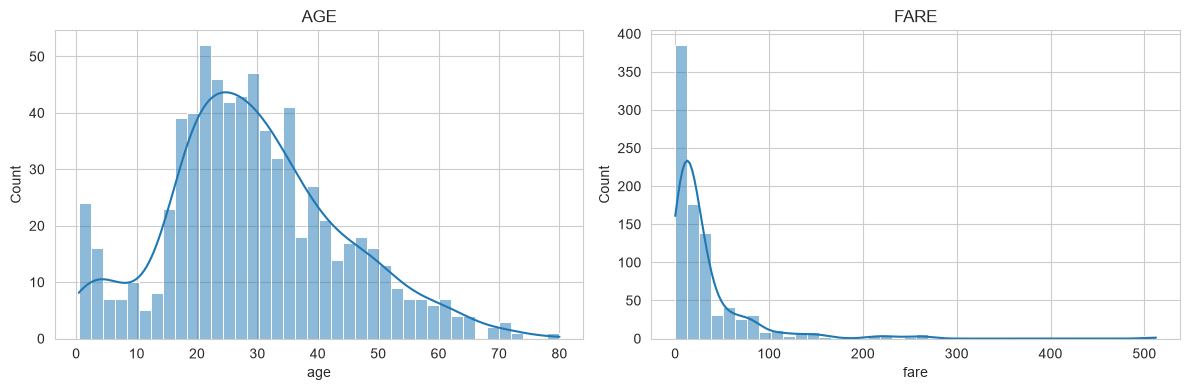

Nhận xét: 75% khách hàng có tuổi <=38 chủ yếu là từ 20-40 tuổi, đồ thị tuổi lệch phải
Nhận xét: giá vé lệch phải mạnh => phần lớn kh mua giá vé thấp trong khi một số khách hàng có giá vé rất cao. kurtosis rất nặng => có giá trị cực đoan cao


In [60]:
# TODO
for col in ['age', 'fare']:
    s = df[col].dropna()
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"P25={s.quantile(.25):.2f}, P50={s.quantile(.50):.2f}, P75={s.quantile(.75):.2f}")
    print(f"skewness= {skew_:.2f}, kurtosis={kurt_:.2f}")

fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['age'], bins=40, kde=True, ax=axes[0]); axes[0].set_title('AGE')
sns.histplot(df['fare'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('FARE')
plt.tight_layout(); plt.show()

print("Nhận xét: 75% khách hàng có tuổi <=38 chủ yếu là từ 20-40 tuổi, đồ thị tuổi lệch phải")
print("Nhận xét: giá vé lệch phải mạnh => phần lớn kh mua giá vé thấp trong khi một số khách hàng có giá vé rất cao. kurtosis rất nặng => có giá trị cực đoan cao")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [71]:
# TODO
survival_rare = df.groupby('pclass')['survived'].mean()*100
print(f"Hạng vé có tl sống cao/thấp nhất: Hạng {survival_rare.idxmax()}= {survival_rare.max():.2f}%, Hạng {survival_rare.idxmax()}= {survival_rare.min():2f}%")
print(f"Chênh lệch {survival_rare.max()-survival_rare.min():.2f}% so với hạng thấp nhất")


Hạng vé có tl sống cao/thấp nhất: Hạng 1= 62.96%, Hạng 1= 24.236253%
Chênh lệch 38.73% so với hạng thấp nhất


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [ ]:
# TODO
df.groupby(['sex', 'pclass'])['survived'].mean() * 100
print("Nhận xét: giới tính ảnh hưởng tới tỷ lệ sống sót")

sex     pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [ ]:
# TODO
result = df.groupby('pclass')[['fare', 'survived']].mean()
result['survived']*=100
print(result)
print("Nhận xét: giá vé cao hơn có tỷ lệ sống sót cao hơn")

             fare   survived
pclass                      
1       84.154687  62.962963
2       20.662183  47.282609
3       13.675550  24.236253


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [85]:
# TODO

result = df.groupby('family_size').agg(count = ('survived', 'size'), s_rate = ('survived', 'mean'))
result['s_rate'] *=100

print(result)
print("Nhận xét: gia đình đông người có ảnh hưởng tới tỷ lệ sống sót. Tỷ lệ sống sót cao nhất là từ 2-4 người, từ 5 người trở lên tỷ lệ giảm rất mạnh")

             count     s_rate
family_size                  
1              537  30.353818
2              161  55.279503
3              102  57.843137
4               29  72.413793
5               15  20.000000
6               22  13.636364
7               12  33.333333
8                6   0.000000
11               7   0.000000
Nhận xét: gia đình đông người có ảnh hưởng tới tỷ lệ sống sót. Tỷ lệ sống sót cao nhất là từ 2-4 người, từ 5 người trở lên tỷ lệ giảm rất mạnh


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [88]:
# TODO
print(df.groupby('embark_town')['survived'].mean()*100)
print("Nhận xét: cảng Cherbourn có tỷ lệ sống sót cao nhất")

embark_town
Cherbourg      55.357143
Queenstown     38.961039
Southampton    33.695652
Name: survived, dtype: float64
Nhận xét: cảng Cherbourn có tỷ lệ sống sót cao nhất


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Insight:
-Hạng vé 1 có tỷ lệ sống cao nhất: 62,96%, hạng vé 3 có tỷ lệ sống thấp nhất chỉ 38,73%.
-Giới tính có ảnh hưởng tới tỷ lệ sống sót. Tỷ lệ sống sót của vé cho nữ cao hơn nhiều so với cho nam.
-Giá vé có ảnh hưởng tới tỷ lệ sống sót.
-Gia đình đông người có ảnh hưởng tới giá vé. Tỷ lệ sống sót của vé cho gia đình 4 người là cao nhất.
-Cảng lên tàu Cherbourn có tỷ lệ sống sót cao nhất: 55,38%.